## Link Prediction
**Link Prediction** (предсказание связей) - это задача в области графовых знаний, направленная на предсказание отношений (рёбер) между сущностями в графовой структуре. В контексте баз данных знаний, где информация представлена в виде графа, задача link prediction становится важным инструментом для дополнения или обновления существующей сети отношений.

Задача link prediction заключается в предсказании отсутствующих рёбер между сущностями, основываясь на известных связях в графе.

Применения link prediction включают:

> Предсказание новых связей между пользователями или группами.

> Предсказание взаимодействий между белками в биологических сетях.

> Предсказание связей между пользователями и товарами.

> Пополнение базы знаний новыми фактами.

В контексте машинного обучения и графовых моделей, задача link prediction решается с использованием методов, таких как графовые эмбеддинги, глубокие нейронные сети, и другие алгоритмы, специфичные для графовых данных.

### Установка зависимостей


Устанавливаем необходимые для работы зависимости

In [3]:
# Установка Pykeen
!pip install pykeen matplotlib

Далее, импортируем необходимых модулей

In [4]:
import pykeen
import torch
import matplotlib.pyplot as plt
from pykeen.pipeline import pipeline
from pykeen.evaluation import ClassificationEvaluator
from pykeen.datasets import Countries

INFO:pykeen.utils:Using opt_einsum


В этой работе мы снова будем использовать уже известный dataset Nations

In [5]:
# Загрузка графового датасета Countries
countries_dataset = Countries()

Проверяем доступность GPU для вычислений

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Метрики для оценки работы модели

В рамках этой работы мы рассмотрим несколько classification метрик.

#### **ROC-AUC Score (Receiver Operating Characteristic - Площадь под кривой):**

> **ROC-AUC** - это метрика, используемая для оценки производительности бинарной классификационной модели.

> Измеряет площадь под кривой ROC, которая отображает соотношение верно положительных случаев к ложно положительным случаям при различных значениях порога.

> Более высокий показатель ROC-AUC указывает на лучшую дискриминацию между положительными и отрицательными случаями.

#### **Precision:**

> **Precision** - это метрика, оценивающая точность положительных предсказаний классификационной модели.

> Рассчитывается как отношение верно положительных предсказаний к общему числу положительных предсказаний (верно положительные + ложно положительные).

> Precision особенно важна, когда стоимость ложно положительных случаев высока.

#### **Accuracy:**

>  **Accuracy** - простая метрика, измеряющая общую правильность классификационной модели.

> Рассчитывается как отношение правильно предсказанных случаев (верно положительные + верно отрицательные) к общему числу случаев.

> В то время как Accuracy легко интерпретировать, она может быть несостоятельной для несбалансированных наборов данных, где один класс значительно превосходит другой.

#### **F1-мера (F1 Score):**

> **F1-мера** - это гармоническое среднее точности и полноты.

> Обеспечивает баланс между точностью и полнотой, что делает ее подходящей метрикой для несбалансированных наборов данных.

Эти метрики часто используются для оценки моделей, и их выбор зависит от конкретных целей и характеристик решаемой проблемы. Например, в сценариях, где ложно положительные или ложно отрицательные случаи имеют разные стоимости, могут быть более актуальными точность или полнота. ROC-AUC обеспечивает всесторонний обзор способности модели к дискриминации между классами при различных значениях порога.

In [7]:
#Объявим переменные для хранения рассчитанных метрик
roc_auc_score = []
precision = []
accuracy = []
f1 = []

#Переменная для хранения рразличных пайплайнов pykeen
pipeline_results_list = []

 Чтобы ценить работу модели на наборе данных будем использовать ClassificationEvaluator() позволяющий рассчитывать рассмотренные ранее метрики

In [8]:
evaluator = ClassificationEvaluator()

Обучим модель ComplEx для разного количества эпох, для каждой модели рассчитаем и сохраним значения метрик

In [9]:
# Список значений количества эпох
epochs = [1,20,50,100,250]

for epoch in epochs:

  # Обучаем модель
  pipeline_results = pipeline(
      model="ComplEx",
      dataset=countries_dataset,
      training_kwargs=dict(num_epochs=epoch),
      device=device
  )

  # Сохраняем обученную модель
  pipeline_results_list.append(pipeline_results)

  model = pipeline_results.model
  # Рассчитываем метрики для обученной модели и датасета Nations
  metrics = evaluator.evaluate(model, countries_dataset.testing.mapped_triples,
                             additional_filter_triples=[countries_dataset.training.mapped_triples,
                                                        countries_dataset.validation.mapped_triples])

  # Сохраняем рассчитанные метрики
  roc_auc_score.append(metrics.get_metric('roc_auc_score'))
  precision.append(metrics.get_metric('average_precision_score'))
  accuracy.append(metrics.get_metric('accuracy_score'))
  f1.append(metrics.get_metric('f1_score'))

INFO:pykeen.pipeline.api:Using device: cpu


Training epochs on cpu:   0%|          | 0/1 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0/5 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Currently automatic memory optimization only supports GPUs, but you're using a CPU. Therefore, the batch_size will be set to the default value.
INFO:pykeen.evaluation.evaluator:No evaluation batch_size provided. Setting batch_size to '32'.


Evaluating on cpu:   0%|          | 0.00/24.0 [00:00<?, ?triple/s]

...

INFO:pykeen.evaluation.evaluator:Currently automatic memory optimization only supports GPUs, but you're using a CPU. Therefore, the batch_size will be set to the default value.
INFO:pykeen.evaluation.evaluator:No evaluation batch_size provided. Setting batch_size to '32'.


Evaluating on cpu:   0%|          | 0.00/24.0 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.13s seconds
INFO:pykeen.evaluation.evaluator:Currently automatic memory optimization only supports GPUs, but you're using a CPU. Therefore, the batch_size will be set to the default value.
INFO:pykeen.evaluation.evaluator:No evaluation batch_size provided. Setting batch_size to '32'.


Evaluating on cpu:   0%|          | 0.00/24.0 [00:00<?, ?triple/s]

/usr/local/lib/python3.10/dist-packages/rexmex/metrics/classification.py:484: RuntimeWarning: invalid value encountered in power
  pthr = (fpr**0.5) / (fpr**0.5 + tpr**0.5)
INFO:pykeen.evaluation.evaluator:Evaluation took 0.12s seconds


После того как метрики рассчитаны для разного количества эпох обучения визуализируем полученные метрики

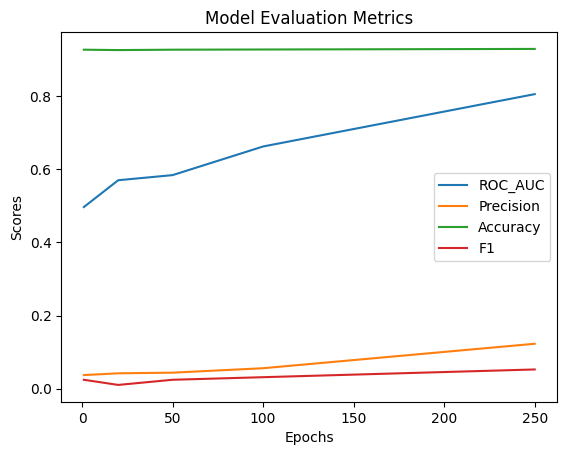

In [10]:
# В качесте лейблов используем список значений эпох
labels = epochs

# Plotting ROC AUC scores
plt.plot(labels, roc_auc_score, label='ROC_AUC')

# Plotting precision scores
plt.plot(labels, precision, label='Precision')

# Plotting accuracy scores
plt.plot(labels, accuracy, label='Accuracy')

# Plotting F1
plt.plot(labels, f1, label='F1')

# Добавляем легенду, лейблы и название
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Scores')
plt.title('Model Evaluation Metrics')

# Отрисовываем график
plt.show()


Далее рассмотрим  метод predict_target(). Основной вариант использования pykeen.predict.predict_target() — прогнозирование ссылок или прогнозирование отношений. Например, мы можем использовать наши модели для оценки всех возможных tail объектов запроса (uk, conferences, ?).

In [11]:
from pykeen.predict import predict_target
for idx, ep in enumerate(epochs):
  pipeline_result = pipeline_results_list[idx]
  pred = predict_target(
      model=pipeline_result.model,
      head="americas",
      relation="locatedin",
      triples_factory=pipeline_result.training,
  )

  pred_filtered = pred.filter_triples(countries_dataset.training)
  pred_annotated = pred_filtered.add_membership_columns(validation=countries_dataset.validation, testing=countries_dataset.testing)
  pred_df = pred_annotated.df[['tail_label','score']]
  print(f'Результат при вычислении {ep} эпох')
  print(pred_df)
  print('__________________________')

Результат при вычислении 1 эпох
                   tail_label      score
196                   réunion  66.746338
146                   mayotte  64.760017
107                 indonesia  63.905960
224           southern_europe  56.027931
174  northern_mariana_islands  52.746910
..                        ...        ...
195                    rwanda -53.253090
230                 swaziland -58.560287
154                montenegro -58.744225
243       trinidad_and_tobago -59.880287
227                     sudan -60.524582

[271 rows x 2 columns]
__________________________
Результат при вычислении 20 эпох
        tail_label      score
117         jersey  81.759552
12           aruba  79.389923
102       honduras  66.290207
259   vatican_city  65.797890
223  southern_asia  57.301010
..             ...        ...
96       guatemala -63.138817
92       greenland -69.950912
31          brazil -70.829575
21        barbados -77.734634
24          belize -86.602501

[271 rows x 2 columns]
________

В результате выполнения лабораторной работы была успешно обучены модели, способная предсказывать связи между сущностями в графовой структуре.

Проведенный анализ с использованием метрик precision, accuracy, F1 и ROC-AUC позволяет сделать следующие выводы:

**Precision, Accuracy, и F1:**

Метрики precision, accuracy и F1 предоставляют информацию о качестве классификации модели. Высокие значения этих метрик указывают на эффективность модели в правильном предсказании связей.

**ROC-AUC:**

ROC-AUC метрика измеряет способность модели различать между положительными и отрицательными классами при различных порогах. Значение ROC-AUC близкое к 1.0 говорит о высокой дискриминации, что подтверждает успешное обучение модели.


Попробуйте обучыить другую модель. Примените обученную модель к другому датасету. Проанализируйте результаты. Хорошим вариантом будет преднамеренно удалить существующую связку и исследовать работу модели на предсказании удаленной связи.